In [3]:
import os
import json

In [4]:
def load_problems(dataset_root):
    # List to store folders with 'images' subfolder
    problems = []

    for subfolder in os.listdir(dataset_root):
        subfolder_path = os.path.join(dataset_root, subfolder)
        with open(os.path.join(subfolder_path, "data.json"), 'r') as file:
            data = json.load(file)
        problems.append((subfolder, data))

    return problems

problems = sorted(
    load_problems("/home/kaixin/Desktop/mmcode/mmcode_dataset"),
    key=lambda x: x[0]
)

In [5]:
len(problems)

4344

In [6]:
problems[0]

('ac_abc045_a',
 {'question': 'You are given a trapezoid. The lengths of its upper base, lower base, and height are $a$, $b$, and $h$, respectively.\n\n![image](1.png)\nAn example of a trapezoid\n\nFind the area of this trapezoid.\n\nConstraints\n\n- $1≦a≦100$\n- $1≦b≦100$\n- $1≦h≦100$\n- All input values are integers.\n- $h$ is even.\n\nInput\nThe input is given from Standard Input in the following format:\n$a$\r\n\n$b$\r\n\n$h$\r\n\nOutput\nPrint the area of the given trapezoid. It is guaranteed that the area is an integer.\n\nSample Input 1\n3\r\n4\r\n2\r\n\nSample Output 1\n7\r\n\nWhen the lengths of the upper base, lower base, and height are $3$, $4$, and $2$, respectively, the area of the trapezoid is $(3+4)×2/2 = 7$.\n\nSample Input 2\n4\r\n4\r\n4\r\n\nSample Output 2\n16\r\n\nIn this case, a parallelogram is given, which is also a trapezoid.',
  'solutions': '["import math\\na = int(input())\\nb = int(input())\\nh = int(input())\\nanswer = (a + b) * h / 2\\nprint(math.ceil(answ

### Remove problems with empty output

In [20]:
missing_io = []
for prob in problems:
    io_data = json.loads(prob[1]["input_output"])
    if len(io_data["outputs"]) == 0:
        missing_io.append(prob)

In [21]:
len(missing_io)

0

In [15]:
import shutil

folder_to_delete = [prob[0] for prob in missing_io]
dataset_root = "/home/kaixin/Desktop/mmcode/mmcode_dataset"
for folder in folder_to_delete:
    # Proceed with caution! This will delete the folder and all its contents
    # shutil.rmtree(os.path.join(dataset_root, folder))

In [8]:
problems_dict = {k: v for k, v in problems}

## Matching

In [5]:
import multiprocessing
from tqdm.notebook import tqdm
import ngram

# Initialize ngram
G = ngram.NGram(N=5)

# Define the function to compare one crawled problem with all taco problems
def find_duplications(problems):
    all_matches = []
    for i, (id_x, problem_x) in tqdm(enumerate(problems), total=len(problems)):
        max_score = -1
        best_match = None

        for id_y, problem_y in problems[i+1:]:
            score = G.compare(problem_x["question"], problem_y["question"])
            if score > max_score:  # Update max_score and best_match if current score is higher
                max_score = score
                best_match = {
                    "x": id_x,
                    "y": id_y,
                    "score": score
                }
        if best_match:
            all_matches.append(best_match)
            

    return all_matches


In [6]:
all_matches = find_duplications(problems)

  0%|          | 0/4446 [00:00<?, ?it/s]

In [7]:
import json

# Serializing the list to JSON
with open('duplications.json', 'w') as file:
    json.dump(all_matches, file)

In [23]:
all_matches

[{'x': 'ac_abc045_a', 'y': 'ac_abc116_a', 'score': 0.35790408525754885},
 {'x': 'ac_abc047_b', 'y': 'ac_arc063_d', 'score': 0.5649458784346378},
 {'x': 'ac_abc054_c', 'y': 'ac_abc075_c', 'score': 0.3496881496881497},
 {'x': 'ac_abc056_b', 'y': 'ac_arc070_c', 'score': 0.49829931972789115},
 {'x': 'ac_abc062_a', 'y': 'ac_agc005_b', 'score': 0.2893815635939323},
 {'x': 'ac_abc069_a', 'y': 'ac_abc106_a', 'score': 0.25042301184433163},
 {'x': 'ac_abc075_c', 'y': 'ac_relay2_d', 'score': 0.3701521845851743},
 {'x': 'ac_abc078_b', 'y': 'ac_agc005_c', 'score': 0.28512396694214875},
 {'x': 'ac_abc088_d', 'y': 'ac_abc096_c', 'score': 0.4220934197067849},
 {'x': 'ac_abc096_c', 'y': 'ac_arc081_d', 'score': 0.35692835692835695},
 {'x': 'ac_abc100_a', 'y': 'ac_abc106_a', 'score': 0.2898457583547558},
 {'x': 'ac_abc106_a', 'y': 'ac_abc116_a', 'score': 0.28502415458937197},
 {'x': 'ac_abc113_d', 'y': 'az_2516', 'score': 0.3168},
 {'x': 'ac_abc116_a', 'y': 'ac_agc005_b', 'score': 0.2920353982300885},
 {

In [25]:
filtered_matches = [match for match in all_matches if match["score"] > 0.6]
len(filtered_matches)

86

In [26]:
filtered_matches

[{'x': 'ac_agc006_b', 'y': 'ac_agc006_d', 'score': 0.6795550847457628},
 {'x': 'ac_wtf19_c1', 'y': 'ac_wtf19_c2', 'score': 0.8894009216589862},
 {'x': 'az_CGL_1_A', 'y': 'az_CGL_1_B', 'score': 0.8472527472527472},
 {'x': 'cf_1015_E1', 'y': 'cf_1015_E2', 'score': 0.9995782370307887},
 {'x': 'cf_1118_F1', 'y': 'cf_1118_F2', 'score': 0.6099585062240664},
 {'x': 'cf_1129_A1', 'y': 'cf_1129_A2', 'score': 0.9529863985807214},
 {'x': 'cf_1133_F1', 'y': 'cf_1133_F2', 'score': 0.6067796610169491},
 {'x': 'cf_1141_F1', 'y': 'cf_1141_F2', 'score': 0.9957961114030478},
 {'x': 'cf_1163_C1', 'y': 'cf_1163_C2', 'score': 0.9813414019162885},
 {'x': 'cf_1178_F1', 'y': 'cf_1178_F2', 'score': 0.8486342943854325},
 {'x': 'cf_1181_E1', 'y': 'cf_1181_E2', 'score': 0.9899839743589743},
 {'x': 'cf_1210_F1', 'y': 'cf_1210_F2', 'score': 0.9779735682819384},
 {'x': 'cf_1237_C1', 'y': 'cf_1237_C2', 'score': 0.9856646394439618},
 {'x': 'cf_1304_F1', 'y': 'cf_1304_F2', 'score': 0.9931062449310625},
 {'x': 'cf_1325_

In [ ]:
print(problems_dict["g4g_eae1fbd0ac8f213a833d231e26ba4d829e79dd9c"]['question'])

In [ ]:
print(problems_dict["g4g_intersection-point-in-y-shapped-linked-lists"]['question'])

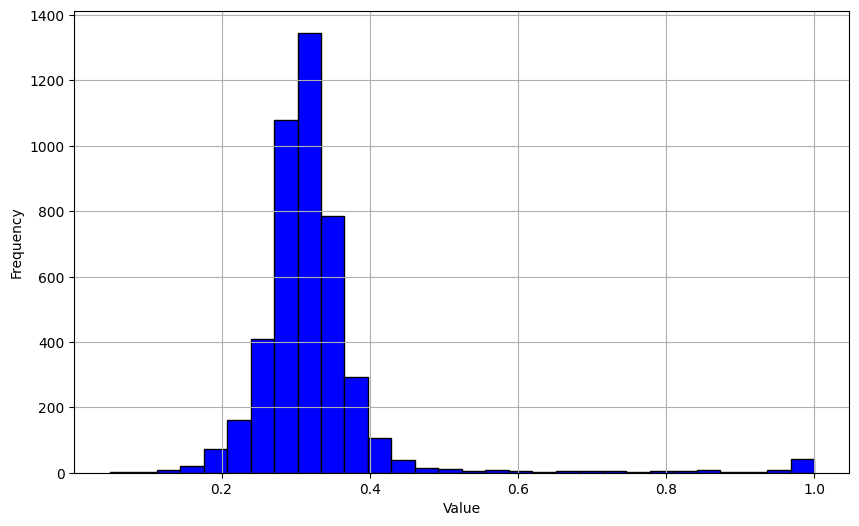

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Creating a histogram
plt.figure(figsize=(10,6))

plt.hist(data, bins=30, color='blue', edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Extraction

In [ ]:
def remove_duplicates(data_list):
    best_by_path = {}
    best_by_id = {}

    # First pass for path
    for item in data_list:
        path = item['crawled_path']
        if path not in best_by_path or (item['score'] > best_by_path[path]['score'] or
                                        (item['score'] == best_by_path[path]['score'] and
                                         item['crawled_path'] > best_by_path[path]['crawled_path'])):
            best_by_path[path] = item

    # Second pass for id
    for item in data_list:
        taco_id = item['taco_id']
        if taco_id not in best_by_id or (item['score'] > best_by_id[taco_id]['score'] or
                                         (item['score'] == best_by_id[taco_id]['score'] and
                                          item['crawled_path'] > best_by_id[taco_id]['crawled_path'])):
            best_by_id[taco_id] = item

    # Combine and get unique items
    unique_items = {item['taco_id']: item for item in best_by_path.values()}
    unique_items.update({item['taco_id']: item for item in best_by_id.values()})

    return list(unique_items.values())

# Remove duplicates and get the unique items
deduped_filtered_data = remove_duplicates(filtered_matches)

len(deduped_filtered_data)

596